<a href="https://colab.research.google.com/github/JOODEID/TESTREPO/blob/main/jeddah_flood_prediction_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jeddah Flood Prediction



In [ ]:
# !pip install -U imbalanced-learn shap xgboost openpyxl

In [1]:
import pandas as pd

excel_path = "Jeddah flooding data.xlsx"
df = pd.read_excel(excel_path)

print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()



Data loaded successfully!
Shape: (3652, 6)


,MO,TE,HU,WS,RR,Y
0,1,24.4,62,7,0.0,0
1,1,23.0,52,11,0.0,0
2,1,23.9,40,8,0.0,0
3,1,11.0,54,8,0.0,0
4,1,11.0,49,8,0.0,0


**libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors import LinearSegmentedcolormap
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
import os
import numpy as np
import pandas as pd
from datetime import datetime

In [ ]:
TARGET_COL = None
CONTINUOUS_TARGET_CANDIDATES = ["flood_probability", "water_depth", "inundation_depth", "hazard_score", "rainfall_mm"]

TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
USE_SMOTE = True
USE_HYPERPARAM_TUNING = False

cool_colors = ["#1f77b4", "#17becf", "#9467bd"]
cool_cm = LinearSegmentedColormap.from_list("cool_cm", ["#eaf4fb", "#89c2d9", "#5e60ce"])

plt.rcParams.update({
    "figure.figsize": (6.8, 4.4),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [ ]:
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMB_AVAILABLE = True
except Exception:
    IMB_AVAILABLE = False

In [ ]:
# Feature engineering
if "rainfall_mm" in df.columns:
    df["rainfall_mm_squared"] = df["rainfall_mm"] ** 2
if "water_depth" in df.columns:
    df["depth_log"] = np.log1p(df["water_depth"])
if set(["rainfall_mm","slope"]).issubset(df.columns):
    df["rain_slope_ratio"] = df["rainfall_mm"] / (df["slope"] + 0.1)
df = df.drop_duplicates().reset_index(drop=True)

Derived target 'MO_binned' from 'MO' via tertiles.
⚠️ Dropping leakage source column used to create target: MO
Target distribution:
MO
Low       1502
Medium    1183
High       903
Name: count, dtype: int64


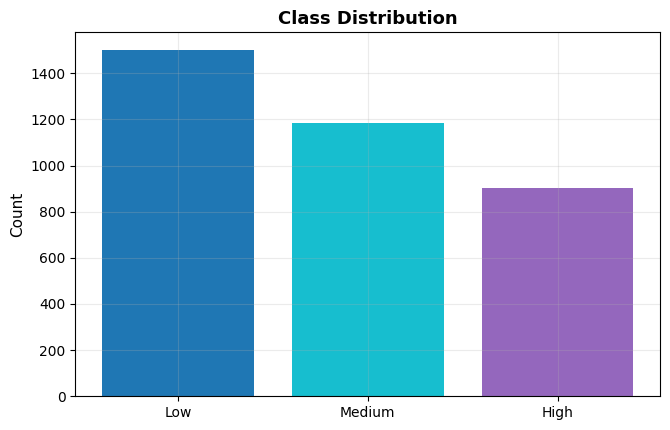

In [ ]:
def guess_target_column(df):
    candidate_names = ["risk","class","label","FloodRisk","flood_risk","RiskClass","Risk"]
    for c in df.columns:
        if str(c).strip() in candidate_names:
            return c, None
    for c in df.columns:
        if c in CONTINUOUS_TARGET_CANDIDATES:
            return None, c
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        return None, numeric_cols[0]
    return None, None

if TARGET_COL is not None and TARGET_COL not in df.columns:
    raise ValueError(f"TARGET_COL '{TARGET_COL}' not found in columns: {list(df.columns)}")

guessed_target, cont_source = (TARGET_COL, None) if TARGET_COL else guess_target_column(df)

if guessed_target is not None:
    y = df[guessed_target].astype(str).str.strip()
    mapping = {"low":"Low","low risk":"Low","0":"Low",
               "medium":"Medium","moderate":"Medium","1":"Medium",
               "high":"High","2":"High"}
    y = y.str.lower().map(mapping).fillna(df[guessed_target].astype(str))
else:
    if cont_source is None:
        raise ValueError("Could not find a target column or a continuous source to derive one.")
    values = pd.to_numeric(df[cont_source], errors="coerce")
    q1, q2 = np.nanpercentile(values, [33.33, 66.67])
    def to_bin(v):
        if np.isnan(v): return np.nan
        if v <= q1: return "Low"
        if v <= q2: return "Medium"
        return "High"
    y = values.apply(to_bin)
    new_col = f"{cont_source}_binned"
    df[new_col] = y
    guessed_target = new_col
    print(f"Derived target '{new_col}' from '{cont_source}' via tertiles.")

mask = y.notna()
df = df.loc[mask].copy()
y = y.loc[mask]

X = df.drop(columns=[c for c in [guessed_target] if c in df.columns])

if isinstance(guessed_target, str) and guessed_target.endswith("_binned"):
    cont_source = guessed_target.replace("_binned", "")
    if cont_source in X.columns:
        print(f"Dropping leakage source column used to create target: {cont_source}")
        X = X.drop(columns=[cont_source])

print("Target distribution:")
print(y.value_counts())

counts = y.value_counts().reindex(["Low","Medium","High"]).fillna(0)
plt.figure()
plt.bar(counts.index, counts.values, color=["#1f77b4","#17becf","#9467bd"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
classes_used = le.classes_
print("Classes:", classes_used)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),
                                             ("cat", categorical_transformer, categorical_features)])

def make_pipeline(estimator):
    if USE_SMOTE and IMB_AVAILABLE:
        return ImbPipeline(steps=[("preprocess", preprocess), ("smote", SMOTE(random_state=42)), ("clf", estimator)])
    else:
        return Pipeline(steps=[("preprocess", preprocess), ("clf", estimator)])

Classes: ['High' 'Low' 'Medium']


In [ ]:
models = {}
models["RandomForest"] = make_pipeline(RandomForestClassifier(random_state=42, n_jobs=-1))
models["GradientBoosting"] = make_pipeline(GradientBoostingClassifier(random_state=42))
if 'XGBClassifier' in globals() and XGB_AVAILABLE:
    models["XGBoost"] = make_pipeline(XGBClassifier(objective="multi:softprob", eval_metric="mlogloss",
                                                    random_state=42, n_estimators=800,
                                                    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, n_jobs=-1))

param_spaces = {
    "RandomForest": {
        "clf__n_estimators": [600, 900, 1200],
        "clf__max_depth": [None, 12, 18, 24, 30],
        "clf__min_samples_split": [2, 4, 8, 12],
        "clf__min_samples_leaf": [1, 2, 3, 4],
        "clf__max_features": ["sqrt", "log2", None]
    },
    "GradientBoosting": {
        "clf__n_estimators": [300, 500, 800],
        "clf__learning_rate": [0.03, 0.05, 0.08],
        "clf__max_depth": [2, 3, 4]
    }
}
if "XGBoost" in models:
    param_spaces["XGBoost"] = {
        "clf__n_estimators": [600, 800, 1200],
        "clf__max_depth": [3, 4, 6, 8],
        "clf__learning_rate": [0.02, 0.05, 0.08],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0]
    }

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in models.items():
    if USE_HYPERPARAM_TUNING and name in param_spaces:
        search = RandomizedSearchCV(pipe, param_distributions=param_spaces[name], n_iter=35,
                                    scoring="f1_macro", n_jobs=-1, cv=cv, random_state=42, refit=True, verbose=1)
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
    else:
        best_models[name] = pipe.fit(X_train, y_train)

list(best_models.keys())

['RandomForest', 'GradientBoosting', 'XGBoost']


=== RandomForest ===
              precision    recall  f1-score   support

        High       0.54      0.52      0.53       181
         Low       0.74      0.68      0.71       300
      Medium       0.79      0.89      0.84       237

    accuracy                           0.71       718
   macro avg       0.69      0.70      0.69       718
weighted avg       0.71      0.71      0.71       718



<Figure size 680x440 with 0 Axes>

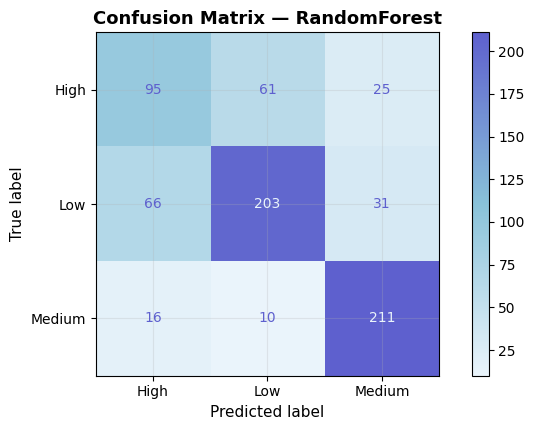

<Figure size 680x440 with 0 Axes>

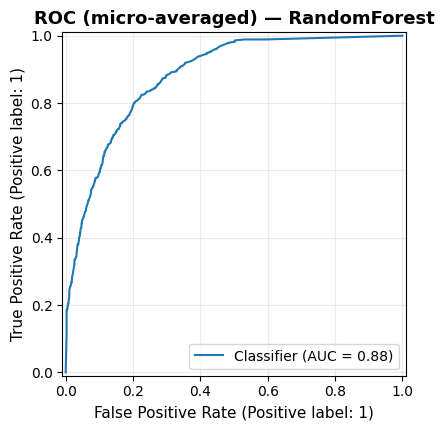

<Figure size 680x440 with 0 Axes>

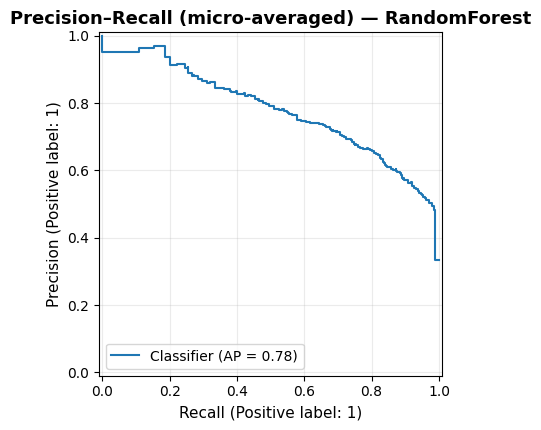


=== GradientBoosting ===
              precision    recall  f1-score   support

        High       0.60      0.59      0.59       181
         Low       0.78      0.71      0.74       300
      Medium       0.81      0.91      0.85       237

    accuracy                           0.74       718
   macro avg       0.73      0.73      0.73       718
weighted avg       0.74      0.74      0.74       718



<Figure size 680x440 with 0 Axes>

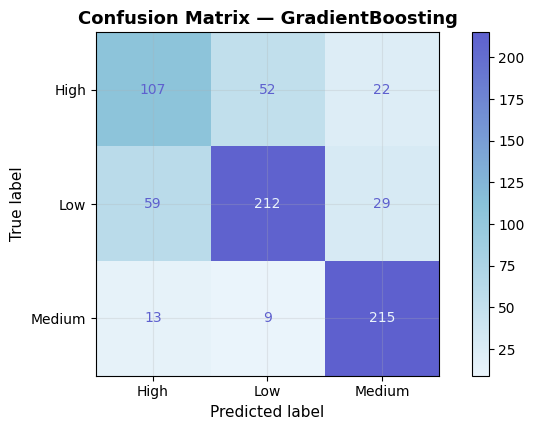

<Figure size 680x440 with 0 Axes>

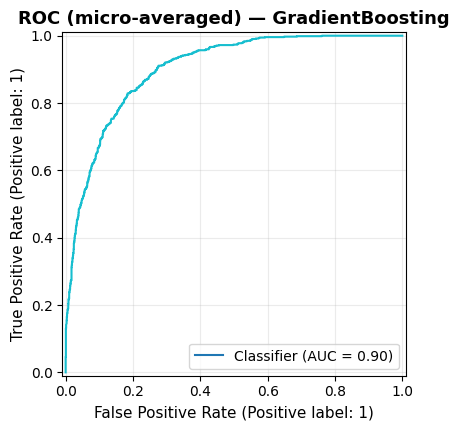

<Figure size 680x440 with 0 Axes>

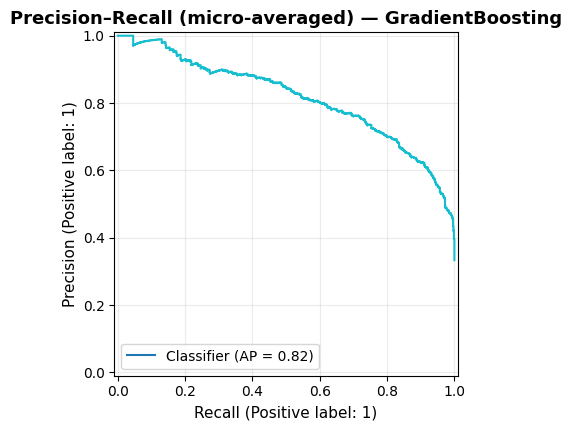


=== XGBoost ===
              precision    recall  f1-score   support

        High       0.55      0.53      0.54       181
         Low       0.75      0.69      0.72       300
      Medium       0.80      0.90      0.85       237

    accuracy                           0.72       718
   macro avg       0.70      0.71      0.70       718
weighted avg       0.71      0.72      0.72       718



<Figure size 680x440 with 0 Axes>

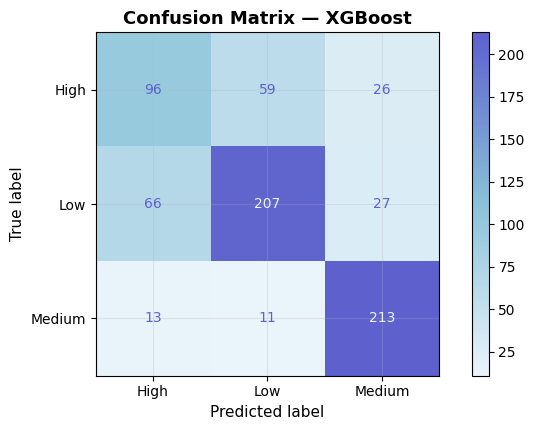

<Figure size 680x440 with 0 Axes>

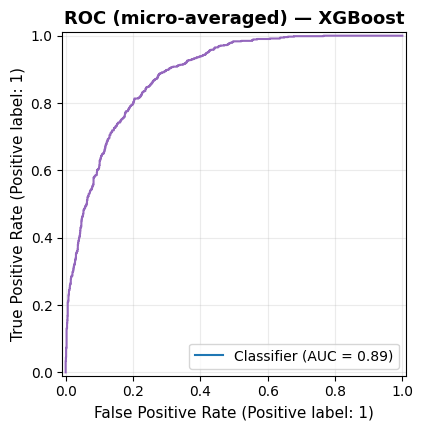

<Figure size 680x440 with 0 Axes>

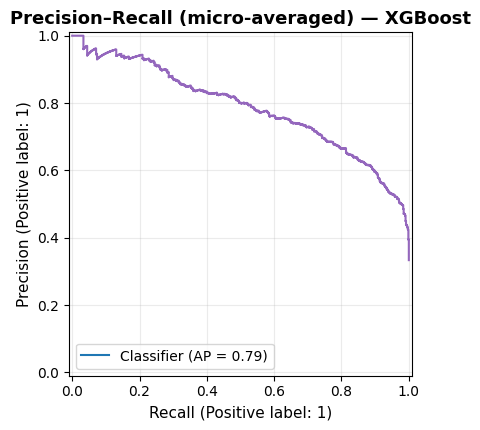

In [ ]:
def eval_and_plot(model, name, X_test, y_test, classes_used, color="#1f77b4"):
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)
    except Exception:
        y_proba = None

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in classes_used]))

    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes_used, cmap=cool_cm)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    if y_proba is not None:
        y_test_bin = label_binarize(y_test, classes=np.arange(len(classes_used)))

        plt.figure()
        RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_proba.ravel())
        for line in plt.gca().get_lines(): line.set_color(color)
        plt.title(f"ROC (micro-averaged) — {name}")
        plt.tight_layout()
        plt.show()

        plt.figure()
        PrecisionRecallDisplay.from_predictions(y_test_bin.ravel(), y_proba.ravel())
        for line in plt.gca().get_lines(): line.set_color(color)
        plt.title(f"Precision–Recall (micro-averaged) — {name}")
        plt.tight_layout()
        plt.show()

colors = ["#1f77b4", "#17becf", "#9467bd"]
for (name, model), color in zip(best_models.items(), colors):
    eval_and_plot(model, name, X_test, y_test, classes_used, color=color)

,Model,Accuracy,F1_macro,ROC_AUC_micro
1,GradientBoosting,0.743733,0.729760,0.901264
2,XGBoost,0.718663,0.701250,0.886275
0,RandomForest,0.708914,0.691782,0.880305


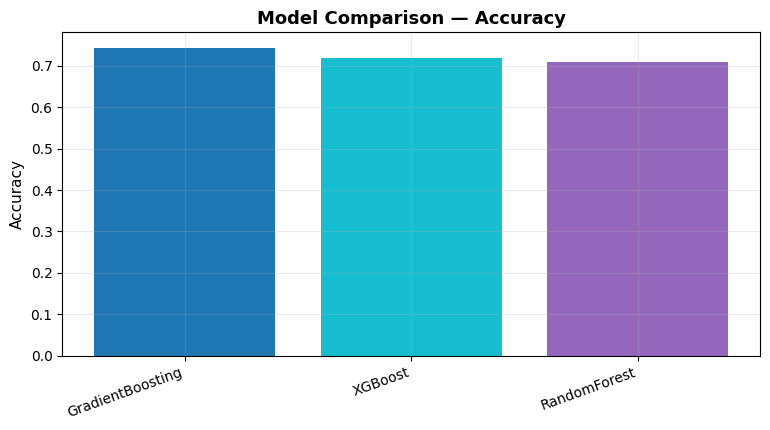

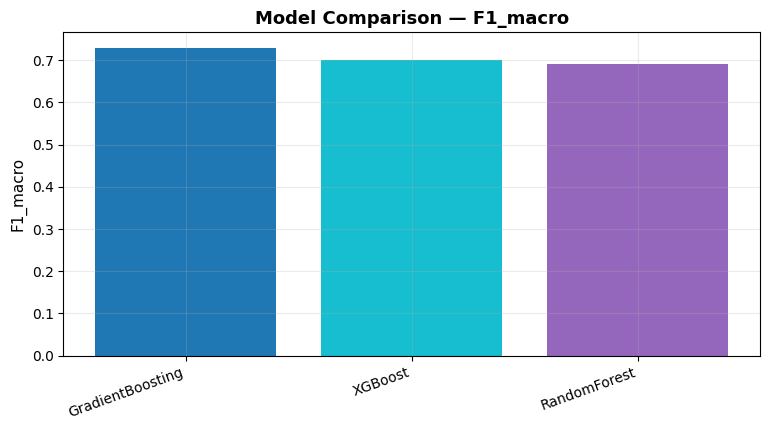

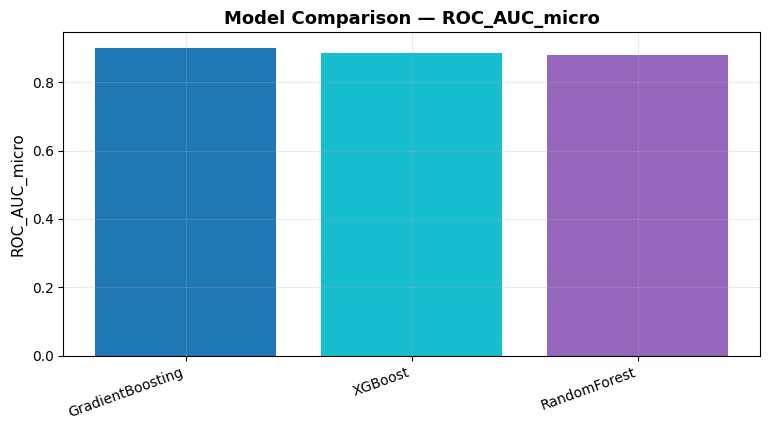

In [ ]:
metrics_table = []
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes_used)))

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    row = {"Model": name}
    row["Accuracy"] = accuracy_score(y_test, y_pred)
    row["F1_macro"] = f1_score(y_test, y_pred, average="macro")
    try:
        y_proba = model.predict_proba(X_test)
        row["ROC_AUC_micro"] = roc_auc_score(y_test_bin, y_proba, average="micro", multi_class="ovr")
    except Exception:
        row["ROC_AUC_micro"] = np.nan
    metrics_table.append(row)

metrics_df = pd.DataFrame(metrics_table).sort_values("F1_macro", ascending=False)
display(metrics_df)

for metric in ["Accuracy", "F1_macro", "ROC_AUC_micro"]:
    plt.figure(figsize=(7.8,4.4))
    vals = metrics_df[metric].values
    labels = metrics_df["Model"].values
    colors = ["#1f77b4", "#17becf", "#9467bd"][:len(vals)]
    plt.bar(range(len(vals)), vals, color=colors)
    plt.xticks(range(len(vals)), labels, rotation=20, ha="right")
    plt.title(f"Model Comparison — {metric}")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

🔥 Highly suspect single features (>=0.99 acc): []


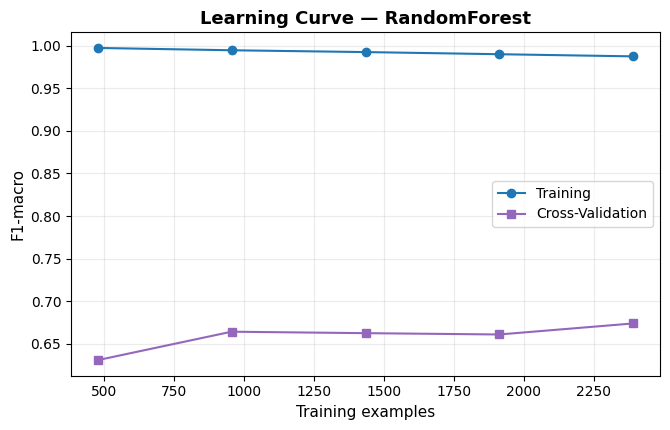

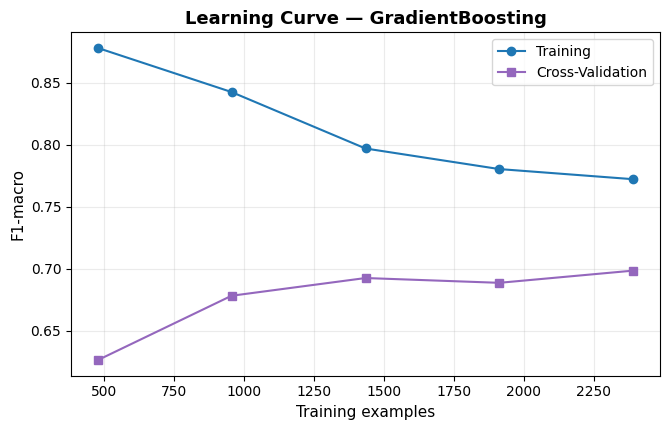

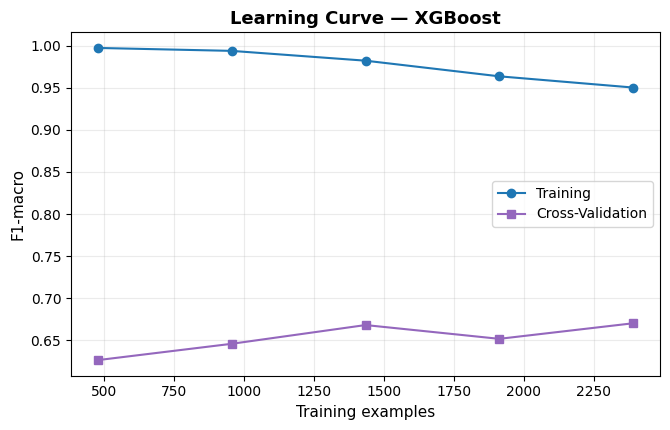

In [ ]:
# Leakage suspects (single-feature stump)
suspects = []
for c in X.columns:
    stump = Pipeline(steps=[
        ("colsel", ColumnTransformer([("sel","passthrough",[c])], remainder="drop")),
        ("clf", DecisionTreeClassifier(max_depth=1, random_state=42))
    ])
    stump.fit(X_train, y_train)
    acc = stump.score(X_test, y_test)
    if acc >= 0.99:
        suspects.append((c, acc))
print(" Highly suspect single features (>=0.99 acc):", sorted(suspects, key=lambda x: -x[1])[:10])

# Learning curves
def plot_learning_curve(estimator, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y_enc, cv=3, n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring="f1_macro"
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, marker="o", label="Training", color="#1f77b4")
    plt.plot(train_sizes, test_mean, marker="s", label="Cross-Validation", color="#9467bd")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1-macro")
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, model in best_models.items():
    plot_learning_curve(model, f"Learning Curve — {name}")

In [ ]:
# Prediction cell
best_name = None
best_score = -1
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred, average="macro")
    if score > best_score:
        best_score, best_name = score, name

best_model = best_models[best_name]
print(f"Selected best model by F1-macro: {best_name} (score={best_score:.4f})")

# Calibrate probabilities if supported
try:
    calibrated = CalibratedClassifierCV(best_model.named_steps["clf"], method="isotonic", cv=3)
    X_train_trans = best_model.named_steps["preprocess"].fit_transform(X_train)
    calibrated.fit(X_train_trans, y_train)
    best_model_calibrated = Pipeline(steps=[("preprocess", best_model.named_steps["preprocess"]), ("clf", calibrated)])
except Exception:
    best_model_calibrated = best_model

print('Create a DataFrame "new_data" with SAME columns as X to predict.')
print(pd.DataFrame(columns=X.columns).head(2))

# Example:
# new_data = pd.DataFrame([{
#     'rainfall_mm': 55.0,
#     'water_depth': 0.12,
#     'slope': 3.5,
#     'landuse': 'Residential',
#     # ... fill rest of required columns
# }])
# proba = best_model_calibrated.predict_proba(new_data)
# idx = np.argmax(proba, axis=1)
# labels = [classes_used[i] for i in idx]
# for i, lab in enumerate(labels):
#     print(f'Predicted flood risk: {lab} (prob={proba[i, idx[i]]:.3f})')

Selected best model by F1-macro: GradientBoosting (score=0.7298)
Create a DataFrame "new_data" with SAME columns as X to predict.
Empty DataFrame
Columns: [TE, HU, WS, RR, Y]
Index: []


## Digital Twin Prototype (Dynamic DT)

The Digital Twin (DT) here is implemented as a **dynamic state table** (a pandas DataFrame).
At each update, new meteorological inputs are passed through the selected AI model, and the DT table is refreshed with:
- `ai_risk_label` (Low/Medium/High)
- `ai_confidence` (probability of the predicted class)
- `recommended_action` (simple rule-based decision support)


In [ ]:
#Define pilot neighborhoods
NEIGHBORHOODS = ["Al-Samer", "AL-Naseem", "Al-Rughamah"]

# Map risk labels to a numeric score
RISK_VALUE_MAP = {"Low": 0.2, "Medium": 0.5, "High": 0.9}

# Digital Twin state table (one row per neighborhood)
twin_df = pd.DataFrame({
    "neighborhood": NEIGHBORHOODS,
    "timestamp": [None]*len(NEIGHBORHOODS),
    "ai_risk_label": [None]*len(NEIGHBORHOODS),
    "ai_confidence": [None]*len(NEIGHBORHOODS),
    "ai_risk_value": [None]*len(NEIGHBORHOODS),
    "recommended_action": [None]*len(NEIGHBORHOODS),
})
twin_df

,neighborhood,timestamp,ai_risk_label,ai_confidence,ai_risk_value,recommended_action
0,Al-Samer,None,None,None,None,None
1,AL-Naseem,None,None,None,None,None
2,Al-Rughamah,None,None,None,None,None


In [ ]:
# --- 2) Decision rules (edit to match your stormwater management logic) ---
def management_action(risk_label: str, conf: float) -> str:
    if risk_label == "High" and conf >= 0.75:
        return "Trigger alert + prioritize drainage inspection"
    if risk_label == "Medium":
        return "Increase monitoring + prepare resources"
    return "Normal monitoring"

In [ ]:
# Digital Twin update function (AI output -> DT state)
def update_twin_state(twin_df: pd.DataFrame, weather_row: pd.DataFrame) -> pd.DataFrame:
    """
    weather_row: DataFrame with exactly 1 row and SAME columns as training features X.
    Returns updated twin_df.
    """
    # Align and validate columns
    weather_row = weather_row.copy()
    weather_row = weather_row.reindex(columns=X.columns, fill_value=0)

    # AI prediction
    proba = best_model.predict_proba(weather_row)  # (1, n_classes)
    pred_idx = int(np.argmax(proba, axis=1)[0])
    pred_label = str(classes_used[pred_idx])
    pred_conf = float(np.max(proba))
    risk_value = float(RISK_VALUE_MAP.get(pred_label, 0.5))

    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    out = twin_df.copy()
    out["timestamp"] = ts
    out["ai_risk_label"] = pred_label
    out["ai_confidence"] = pred_conf
    out["ai_risk_value"] = risk_value
    out["recommended_action"] = management_action(pred_label, pred_conf)
    return out

In [ ]:
# Run ONE update using a real sample row from the dataset (baseline)
# Use any row you like. Here we take the last row of X as an example.
base_weather = X.iloc[[-1]].copy()
twin_df = update_twin_state(twin_df, base_weather)
twin_df

,neighborhood,timestamp,ai_risk_label,ai_confidence,ai_risk_value,recommended_action
0,Al-Samer,2026-03-09 19:00:59,Low,0.617268,0.2,Normal monitoring
1,AL-Naseem,2026-03-09 19:00:59,Low,0.617268,0.2,Normal monitoring
2,Al-Rughamah,2026-03-09 19:00:59,Low,0.617268,0.2,Normal monitoring


In [ ]:
#Scenario analysis: vary rainfall (or any weather variable) and update the DT
# This creates a Scenario-based Dynamic Digital Twin update

# Detect rainfall column name automatically
RAIN_COL = None
for c in X.columns:
    if str(c).strip().lower() in ["rain", "rainfall", "rr", "precip", "precipitation"]:
        RAIN_COL = c
        break
print("Detected rainfall column:", RAIN_COL)

if RAIN_COL is None:
    raise ValueError("Could not detect rainfall column. Please set RAIN_COL manually, e.g., RAIN_COL='RR'")

# Base weather row. You can choose any row.
base_weather = X.iloc[[-1]].copy()

# Define scenarios (mm). Adjust as needed to see Medium/High transitions.
scenarios = {
    "Normal": 5,
    "Moderate": 20,
    "Heavy": 45,
    "Extreme": 80,
}

# Folder to store scenario snapshots (CSV)
out_dir = "/mnt/data/dt_scenarios"
os.makedirs(out_dir, exist_ok=True)

scenario_history = []

for name, rr in scenarios.items():
    weather = base_weather.copy()
    weather[RAIN_COL] = rr

    # Update DT state using the helper you defined above
    twin_snapshot = update_twin_state(twin_df, weather)

    # Add scenario metadata
    twin_snapshot = twin_snapshot.copy()
    twin_snapshot["scenario"] = name
    twin_snapshot["scenario_rain_mm"] = rr

    scenario_history.append(twin_snapshot)

    # Save each scenario snapshot for mapping / reporting
    snap_path = os.path.join(out_dir, f"dt_snapshot_{name}.csv")
    twin_snapshot.to_csv(snap_path, index=False)

# Combine all scenario states into one table
scenario_history_df = pd.concat(scenario_history, ignore_index=True)
print("Scenario runs complete. Combined shape:", scenario_history_df.shape)
print("Saved per-scenario CSV snapshots in:", out_dir)

# Quick preview
scenario_history_df.head(10)


Detected rainfall column: RR
✅ Scenario runs complete. Combined shape: (12, 8)
Saved per-scenario CSV snapshots in: /mnt/data/dt_scenarios


,neighborhood,timestamp,ai_risk_label,ai_confidence,ai_risk_value,recommended_action,scenario,scenario_rain_mm
0,Al-Samer,2026-03-09 19:00:59,Low,0.886180,0.2,Normal monitoring,Normal,5
1,AL-Naseem,2026-03-09 19:00:59,Low,0.886180,0.2,Normal monitoring,Normal,5
2,Al-Rughamah,2026-03-09 19:00:59,Low,0.886180,0.2,Normal monitoring,Normal,5
3,Al-Samer,2026-03-09 19:00:59,Low,0.830351,0.2,Normal monitoring,Moderate,20
4,AL-Naseem,2026-03-09 19:00:59,Low,0.830351,0.2,Normal monitoring,Moderate,20
5,Al-Rughamah,2026-03-09 19:00:59,Low,0.830351,0.2,Normal monitoring,Moderate,20
6,Al-Samer,2026-03-09 19:00:59,Low,0.886188,0.2,Normal monitoring,Heavy,45
7,AL-Naseem,2026-03-09 19:00:59,Low,0.886188,0.2,Normal monitoring,Heavy,45
8,Al-Rughamah,2026-03-09 19:00:59,Low,0.886188,0.2,Normal monitoring,Heavy,45
9,Al-Samer,2026-03-09 19:00:59,Low,0.698547,0.2,Normal monitoring,Extreme,80


✅ Saved:
 - /mnt/data/digital_twin_latest_state.csv
 - /mnt/data/digital_twin_scenarios_history.csv
Risk value pivot (mean):


scenario,Extreme,Heavy,Moderate,Normal
neighborhood,,,,
AL-Naseem,0.2,0.2,0.2,0.2
Al-Rughamah,0.2,0.2,0.2,0.2
Al-Samer,0.2,0.2,0.2,0.2


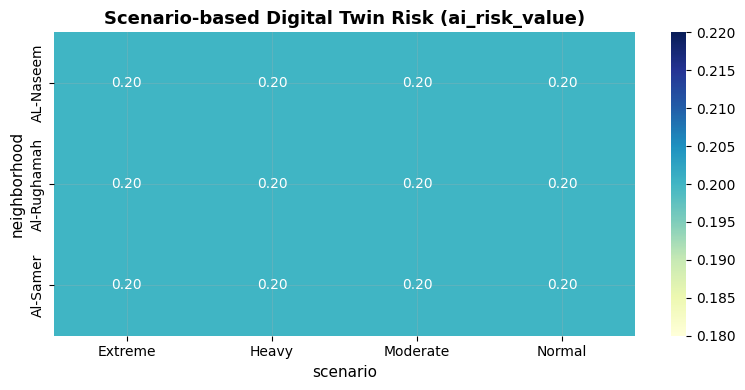

In [ ]:
#Export DT outputs
out_latest = "/mnt/data/digital_twin_latest_state.csv"

# Scenario history (all scenarios combined)
out_scenarios = "/mnt/data/digital_twin_scenarios_history.csv"

# Save
twin_df.to_csv(out_latest, index=False)
scenario_history_df.to_csv(out_scenarios, index=False)

print("Saved:")
print(" -", out_latest)
print(" -", out_scenarios)

# Optional: Create a compact pivot table (Neighborhood x Scenario) for quick inspection
pivot = scenario_history_df.pivot_table(index="neighborhood", columns="scenario", values="ai_risk_value", aggfunc="mean")
print("Risk value pivot (mean):")
display(pivot)

# Optional visualization
try:
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title("Scenario-based Digital Twin Risk (ai_risk_value)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("(Optional heatmap skipped)", e)



## ✅ Digital Twin Results

This section prints and visualizes the main outputs:
- Latest Digital Twin state table
- Scenario history (first rows)
- Scenario summary (counts by risk class)
- Heatmap of risk values (cold color palette)




In [ ]:
if isinstance(out_latest, str):
    out_latest_df = pd.read_csv(out_latest)
else:
    out_latest_df = out_latest.copy()


if isinstance(out_scenarios, str):
    out_scenarios_df = pd.read_csv(out_scenarios)
else:
    out_scenarios_df = out_scenarios.copy()

# Show latest DT state
print("Latest Digital Twin State (latest_state)")
display(out_latest_df)

#Show scenarios history
print(" Scenarios History (first 20 rows)")
display(out_scenarios_df.head(20))

# Summary table: risk counts by scenario
summary_counts = (
    out_scenarios_df
    .groupby(["scenario", "ai_risk_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["scenario", "ai_risk_label"])
)
print(" Scenario × Risk Class counts")
display(summary_counts)

# Pivot for heatmap (neighborhood x scenario)
pivot = out_scenarios_df.pivot_table(
    index="neighborhood",
    columns="scenario",
    values="ai_risk_value",
    aggfunc="mean"
)
print("Pivot table used for heatmap (mean ai_risk_value)")
display(pivot)



📌 Latest Digital Twin State (latest_state)


,neighborhood,timestamp,ai_risk_label,ai_confidence,ai_risk_value,recommended_action
0,Al-Samer,2026-03-09 19:00:59,Low,0.617268,0.2,Normal monitoring
1,AL-Naseem,2026-03-09 19:00:59,Low,0.617268,0.2,Normal monitoring
2,Al-Rughamah,2026-03-09 19:00:59,Low,0.617268,0.2,Normal monitoring


📌 Scenarios History (first 20 rows)


,neighborhood,timestamp,ai_risk_label,ai_confidence,ai_risk_value,recommended_action,scenario,scenario_rain_mm
0,Al-Samer,2026-03-09 19:00:59,Low,0.886180,0.2,Normal monitoring,Normal,5
1,AL-Naseem,2026-03-09 19:00:59,Low,0.886180,0.2,Normal monitoring,Normal,5
2,Al-Rughamah,2026-03-09 19:00:59,Low,0.886180,0.2,Normal monitoring,Normal,5
3,Al-Samer,2026-03-09 19:00:59,Low,0.830351,0.2,Normal monitoring,Moderate,20
4,AL-Naseem,2026-03-09 19:00:59,Low,0.830351,0.2,Normal monitoring,Moderate,20
5,Al-Rughamah,2026-03-09 19:00:59,Low,0.830351,0.2,Normal monitoring,Moderate,20
6,Al-Samer,2026-03-09 19:00:59,Low,0.886188,0.2,Normal monitoring,Heavy,45
7,AL-Naseem,2026-03-09 19:00:59,Low,0.886188,0.2,Normal monitoring,Heavy,45
8,Al-Rughamah,2026-03-09 19:00:59,Low,0.886188,0.2,Normal monitoring,Heavy,45
9,Al-Samer,2026-03-09 19:00:59,Low,0.698547,0.2,Normal monitoring,Extreme,80


📌 Scenario × Risk Class counts


,scenario,ai_risk_label,count
0,Extreme,Low,3
1,Heavy,Low,3
2,Moderate,Low,3
3,Normal,Low,3


📌 Pivot table used for heatmap (mean ai_risk_value)


scenario,Extreme,Heavy,Moderate,Normal
neighborhood,,,,
AL-Naseem,0.2,0.2,0.2,0.2
Al-Rughamah,0.2,0.2,0.2,0.2
Al-Samer,0.2,0.2,0.2,0.2


##  Sensitivity Analysis + Decision Rules (Easy–Medium)

This section strengthens the prototype by:
- running a rainfall grid (0–100 mm)
- extracting probabilities `p_low`, `p_medium`, `p_high`
- computing a continuous **Expected Risk** index
- mapping the index to simple **operational decisions** (Normal / Monitor / Alert)

>


📌 Sensitivity Analysis Results (first 15 rows)


,rain_mm,ai_risk_label,ai_confidence,p_low,p_medium,p_high,expected_risk,decision
0,0,Low,0.617268,0.617268,0.003633,0.379099,0.466459,Monitor
1,5,Low,0.886180,0.886180,0.005215,0.108604,0.277588,Normal
2,10,Low,0.877960,0.877960,0.005481,0.116559,0.283235,Normal
3,15,Low,0.837471,0.837471,0.006204,0.156325,0.311289,Normal
4,20,Low,0.830351,0.830351,0.006476,0.163173,0.316164,Normal
5,25,Low,0.830351,0.830351,0.006476,0.163173,0.316164,Normal
6,30,Low,0.830351,0.830351,0.006476,0.163173,0.316164,Normal
7,35,Low,0.830351,0.830351,0.006476,0.163173,0.316164,Normal
8,40,Low,0.886188,0.886188,0.004809,0.109003,0.277745,Normal
9,45,Low,0.886188,0.886188,0.004809,0.109003,0.277745,Normal


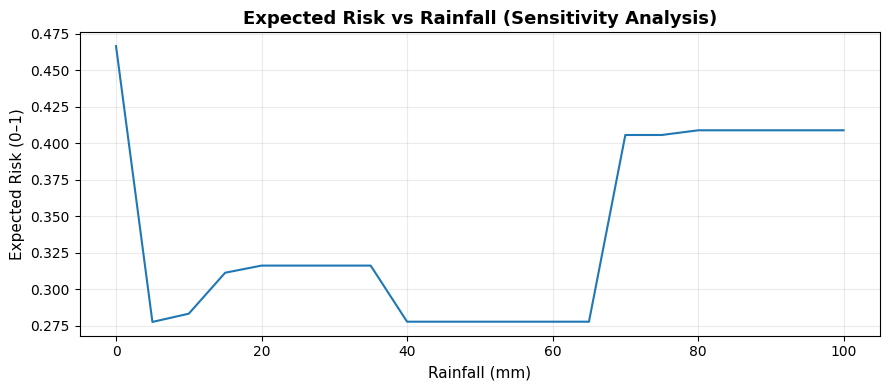

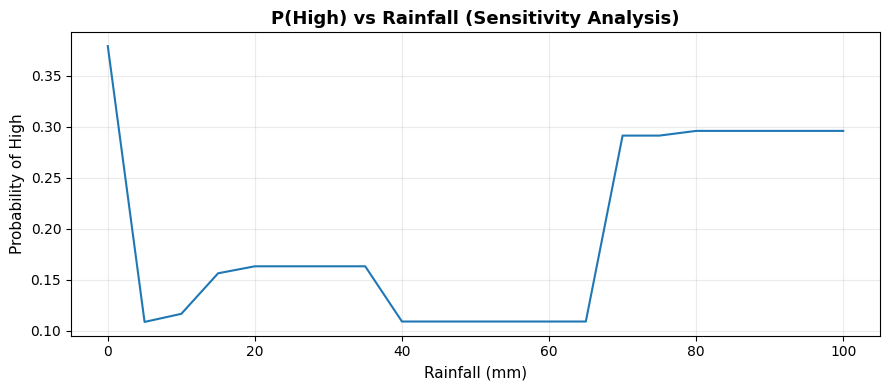

✅ Saved: /mnt/data/sensitivity_analysis_results.csv


In [ ]:
#Settings
RR_COL = "RR"
rain_grid = np.arange(0, 101, 5)

base_weather = X.iloc[[-1]].copy()

# Continuous risk weights (keep consistent with DT mapping)
score_map = {"Low": 0.2, "Medium": 0.5, "High": 0.9}

rows = []
for rr in rain_grid:
    w = base_weather.copy()
    if RR_COL not in w.columns:
        raise ValueError(f"RR_COL='{RR_COL}' not found in X columns. Available columns: {list(w.columns)}")

    w[RR_COL] = rr

    # Probabilities per class
    proba = best_model.predict_proba(w)[0]
    proba_map = dict(zip(classes_used, proba))

    # Predicted label + confidence
    label = classes_used[int(np.argmax(proba))]
    conf = float(np.max(proba))

    # Expected risk index
    expected_risk = sum(proba_map.get(c, 0.0) * score_map[c] for c in score_map)

    # Simple decision rule
    if expected_risk >= 0.60:
        decision = "Alert"
    elif expected_risk >= 0.40:
        decision = "Monitor"
    else:
        decision = "Normal"

    rows.append({
        "rain_mm": rr,
        "ai_risk_label": label,
        "ai_confidence": conf,
        "p_low": proba_map.get("Low", np.nan),
        "p_medium": proba_map.get("Medium", np.nan),
        "p_high": proba_map.get("High", np.nan),
        "expected_risk": expected_risk,
        "decision": decision,
    })

sens_df = pd.DataFrame(rows)
print("Sensitivity Analysis Results (first 15 rows)")
display(sens_df.head(15))

#Plots
plt.figure(figsize=(9,4))
plt.plot(sens_df["rain_mm"], sens_df["expected_risk"])
plt.title("Expected Risk vs Rainfall (Sensitivity Analysis)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Expected Risk (0–1)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(sens_df["rain_mm"], sens_df["p_high"])
plt.title("P(High) vs Rainfall (Sensitivity Analysis)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Probability of High")
plt.grid(True)
plt.tight_layout()
plt.show()

# Save for reporting
sens_out = "/mnt/data/sensitivity_analysis_results.csv"
sens_df.to_csv(sens_out, index=False)
print("Saved:", sens_out)
